# Uncertainty estimate

Recalculate fitness on a random subset of the MSOA admissions data. How consistent are the results?

Can't use wrongness ratio because only have the age band admissions for England-level data, not MSOA-level. Don't know what the correct answer is when some MSOA are excluded.

So have to go by sum of square residuals, which will favour better fits in each deprivation band at the expense of better fits to age bands.

So don't use this for improving fitness, just gauging consistency.

Note - currently not checking for fair splits across depriv levels.

In [1]:
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm

## Load data

### Admissions

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [4]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}'
               for q in qmin_list for a in age_numbers]
# Check the first few:
print(coeff_names[:3])

# Quantile names:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))

['age_less65_q00', 'age_65_q00', 'age_70_q00']


Gather admissions data by deprivation quantile:

In [5]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Best coefficients

In [6]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

Pick out best set of coefficients:

In [7]:
df_best_coeffs = df_best_nudged.filter(df_best_nudged['fitness'] == df_best_nudged['fitness'].min())[0]

Convert to array:

In [8]:
best_coeffs = df_best_coeffs[coeff_names].to_numpy().flatten()

In [9]:
best_coeffs.reshape(5, 5)

array([[0.0006, 0.005 , 0.005 , 0.007 , 0.012 ],
       [0.0005, 0.003 , 0.004 , 0.007 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.005 , 0.011 ],
       [0.0003, 0.002 , 0.002 , 0.005 , 0.011 ]])

## Recalculate admissions

In [10]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [11]:
# Predictions for each MSOA:
predictions_lists = []
sqres_by_depriv = []
for i in range(5):
    coeffs = best_coeffs[(i*5):(i*5)+5]  # coeffs for this depriv.
    yhat = predict_admissions(x_lists[i], coeffs)
    # sum_sqres = find_square_residuals(yhat, admissions_lists[i])
    # Difference from actual:
    sqres_each = np.sqrt((np.array(yhat) - np.array(admissions_lists[i]))**2.0)  # note sqrt
    predictions_lists.append(yhat)
    sqres_by_depriv.append(list(sqres_each))
    
# Combine lists:
observed_all = sum(admissions_lists, [])
predicted_all = sum(predictions_lists, [])
sqres_all = sum(sqres_by_depriv, [])

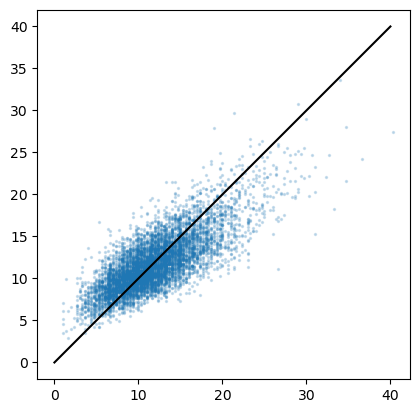

In [12]:
fig, ax = plt.subplots()

ax.scatter(observed_all, predicted_all, s=2, alpha=0.2)
ax.plot([0, 40], [0, 40], color='k')
ax.set_aspect('equal')

plt.show()

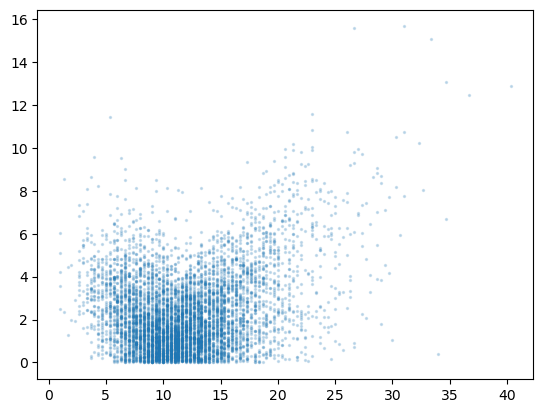

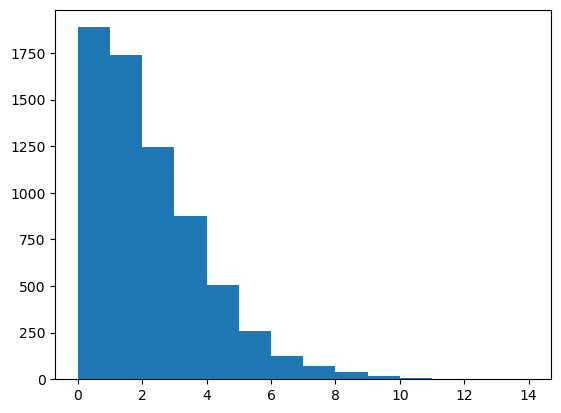

2.2618541533388807 15.65728772 0.00025696899999871903


In [13]:
plt.scatter(observed_all, sqres_all, s=2, alpha=0.2)
plt.show()

plt.hist(sqres_all, bins=np.arange(0, 15, 1))
plt.show()
# 
print(np.mean(sqres_all), np.max(sqres_all), np.min(sqres_all))

### Slice bins

Round each predicted admissions to nearest integer. Group MSOA by these rounded values. Then gather the values of the observed admissions for each group of MSOA.

In [14]:
bins = np.arange(-0.5, np.ceil(max(predicted_all))+0.5, 1.0)

bin_inds = np.digitize(predicted_all, bins)
# Bin index 0 will be for less than -0.5 admissions.
# Bin index 1 is for -0.5 (inclusive) to +0.5 (exclusive).

binned_admissions = []
binned_predictions = []
binned_sqres = []
for b, bin_left in enumerate(bins):
    p = np.where(bin_inds == b+1)
    binned_sqres.append(np.array(sqres_all)[p])
    binned_admissions.append(np.array(observed_all)[p])
    binned_predictions.append(np.array(predicted_all)[p])

In [15]:
binned_means = []
binned_stds = []
binned_lengths = []

for i, b in enumerate(binned_admissions):  # binned_predictions):
    binned_means.append(np.mean(b))
    binned_stds.append(np.std(b))
    binned_lengths.append(len(b))

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  

In [16]:
bins

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5])

In [17]:
bin_inds

array([14, 16, 14, ..., 11, 10, 14])

### Plot means and stds

In [18]:
for i, b in enumerate(binned_admissions):
    print(f'{i:2.0f} {binned_means[i]:5.2f} {binned_stds[i]:5.2f} {len(b)}')

 0   nan   nan 0
 1   nan   nan 0
 2   nan   nan 0
 3  2.11  1.13 3
 4  3.58  1.44 8
 5  4.29  1.59 33
 6  5.62  1.87 113
 7  6.76  2.10 254
 8  8.01  2.46 493
 9  9.01  2.40 754
10 10.11  2.54 933
11 11.11  2.91 869
12 12.10  2.87 816
13 13.09  3.09 700
14 13.98  3.20 540
15 14.95  3.26 422
16 15.84  3.44 246
17 16.99  3.41 200
18 18.54  3.67 139
19 18.90  3.29 72
20 21.26  4.53 60
21 20.60  3.59 43
22 24.19  4.17 35
23 23.68  3.11 22
24 24.29  5.65 8
25 26.81  3.56 12
26 26.14  2.02 7
27 31.83  8.50 2
28 26.83  7.83 2
29 30.00  0.00 1
30 21.33  0.00 1
31 29.00  0.00 1
32   nan   nan 0
33   nan   nan 0
34 34.00  0.00 1


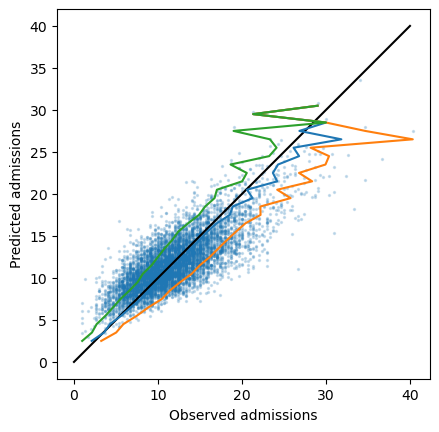

In [19]:
fig, ax = plt.subplots()

ax.scatter(observed_all, predicted_all, s=2, alpha=0.2)
ax.plot([0, 40], [0, 40], color='k')

# Mean +- std:
ax.plot(binned_means, bins)
ax.plot(np.array(binned_means) + np.array(binned_stds), bins)
ax.plot(np.array(binned_means) - np.array(binned_stds), bins)
 
ax.set_aspect('equal')
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Predicted admissions')

plt.show()

Show that slices follow Poisson distribution:

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


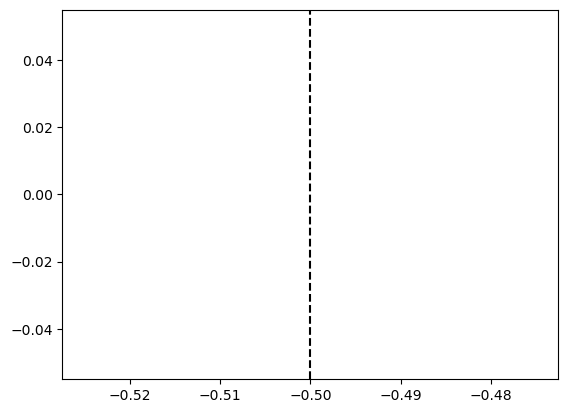

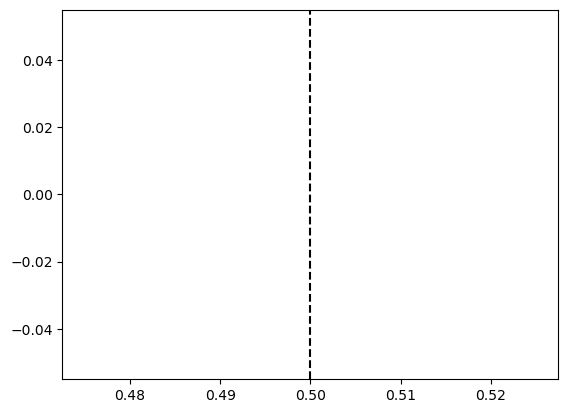

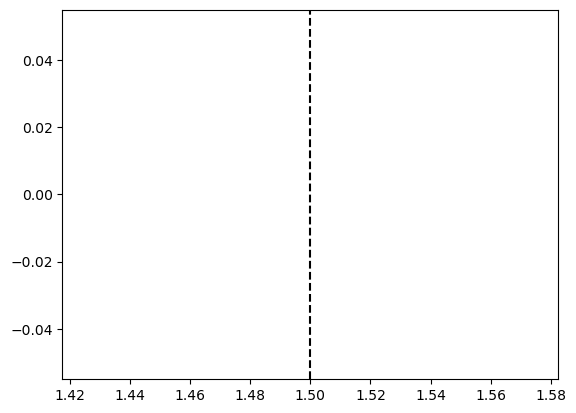

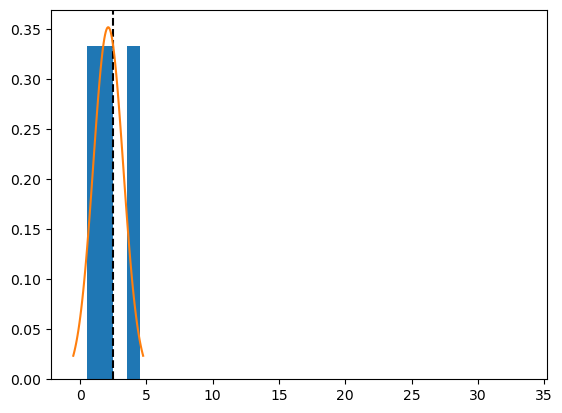

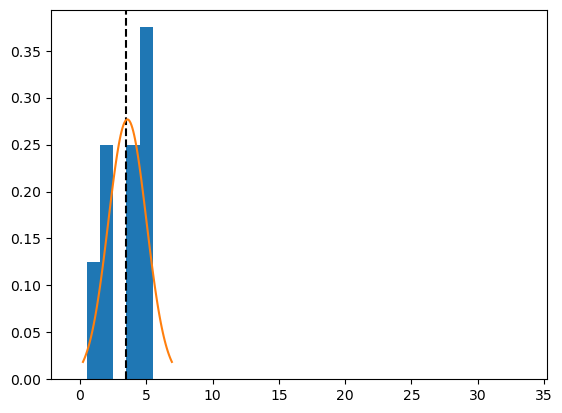

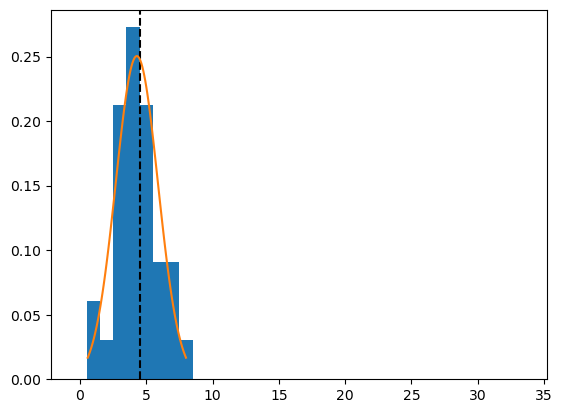

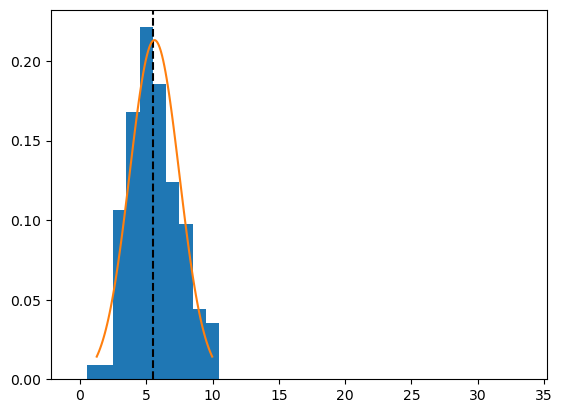

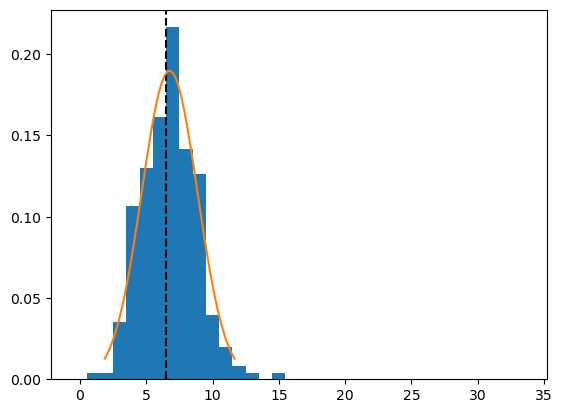

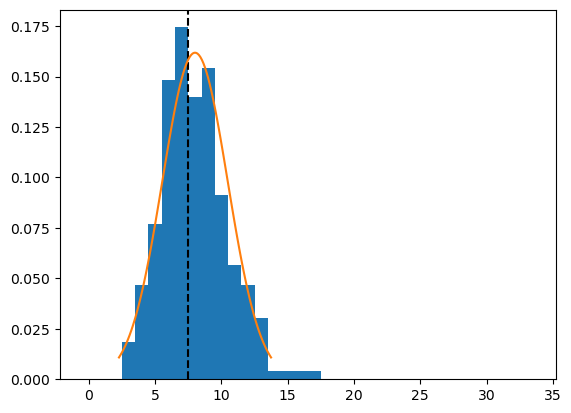

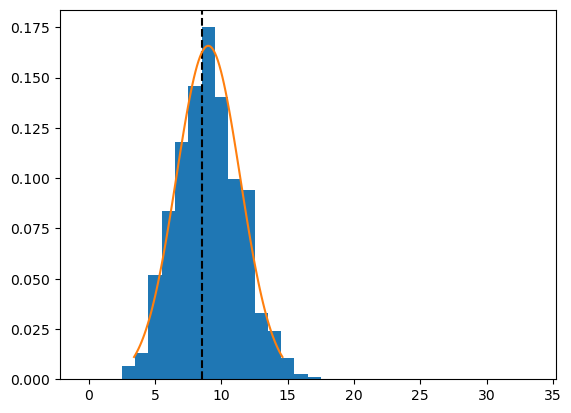

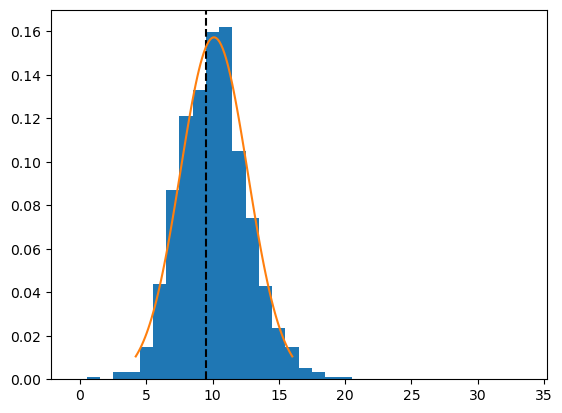

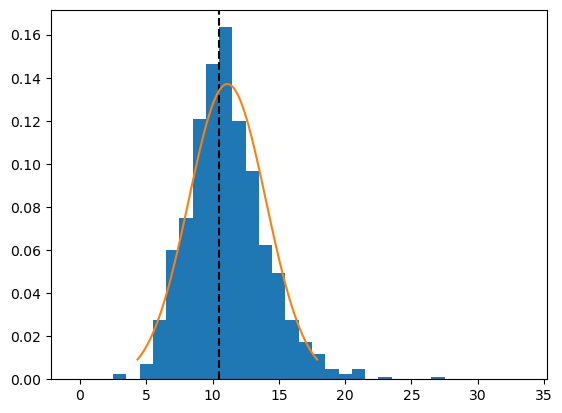

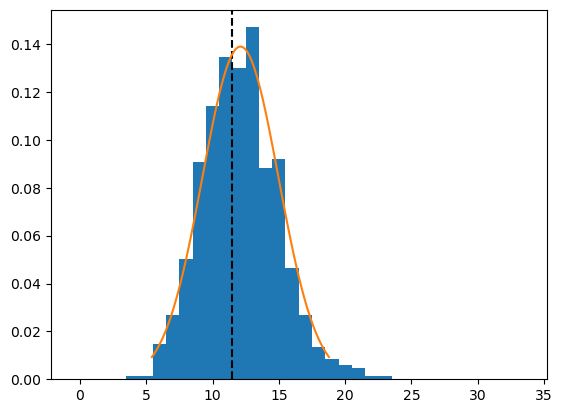

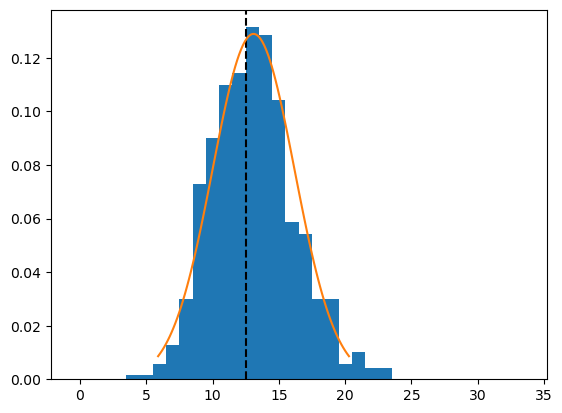

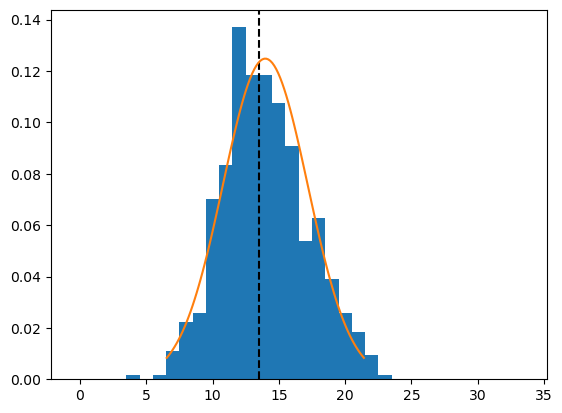

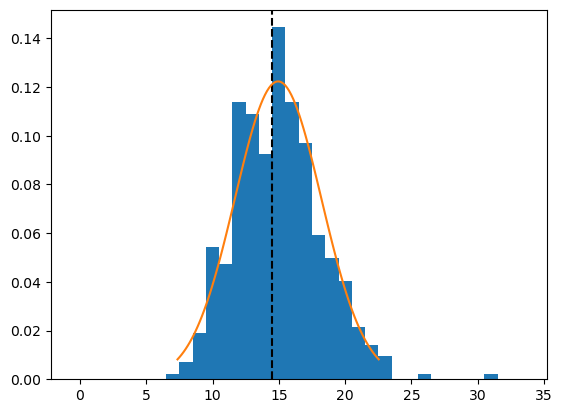

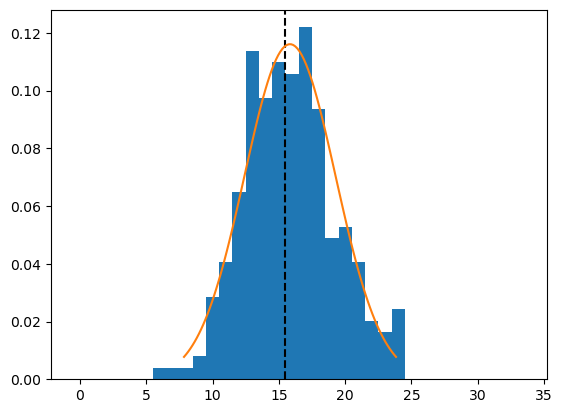

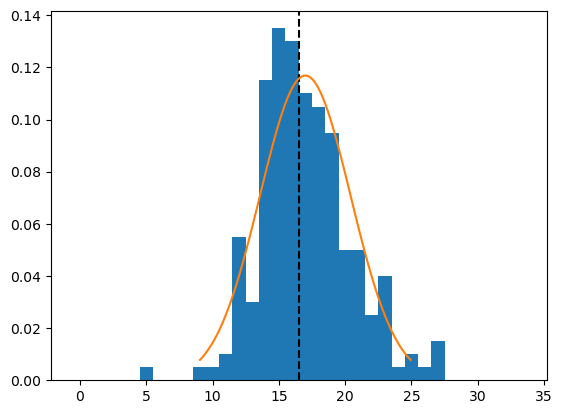

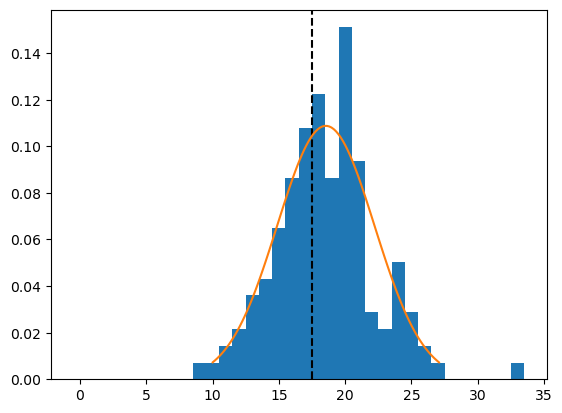

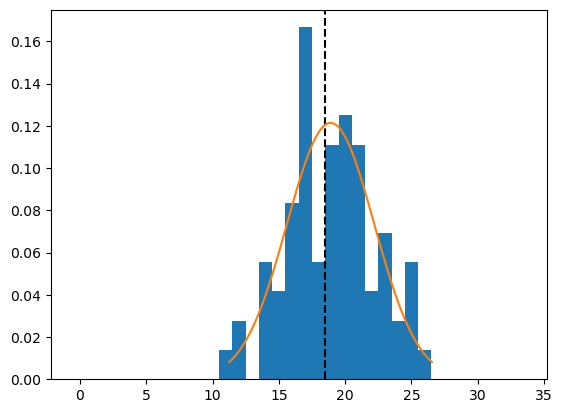

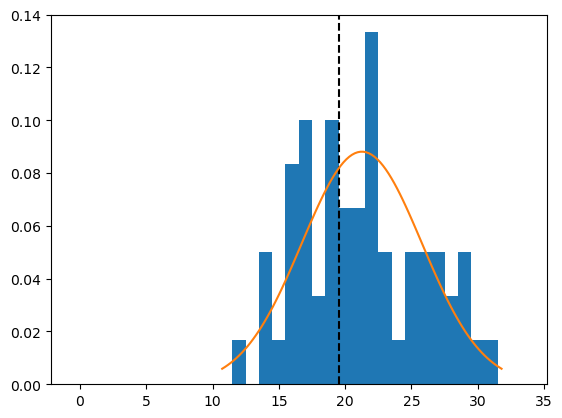

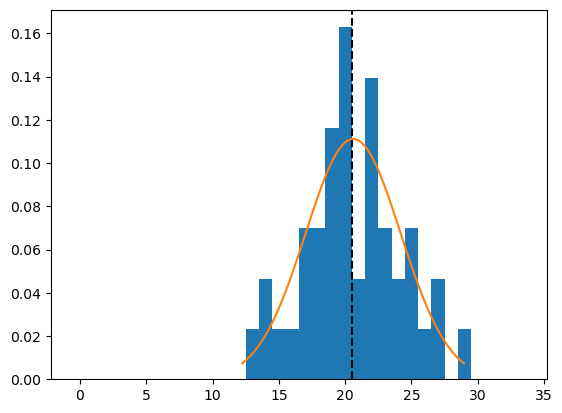

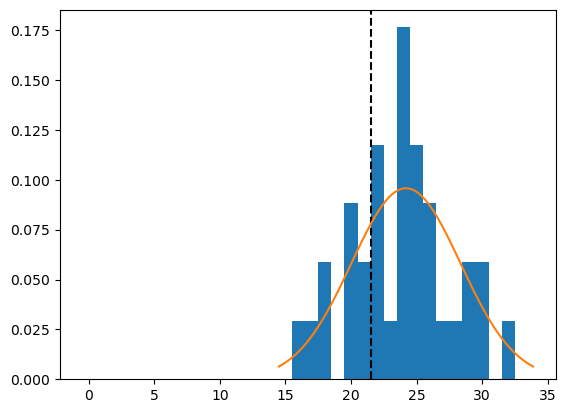

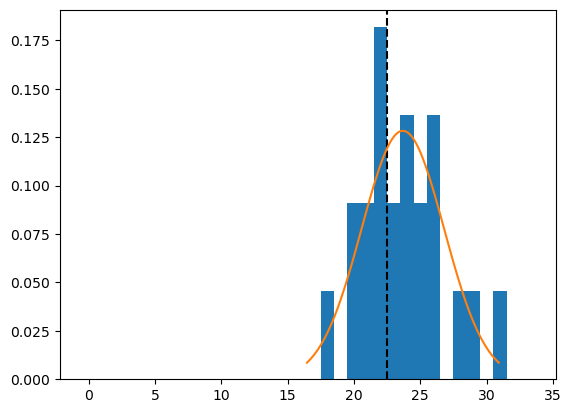

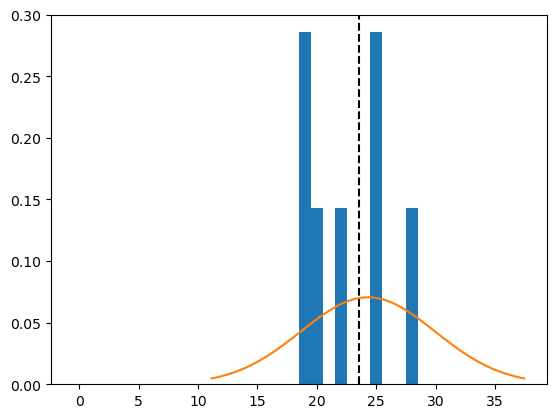

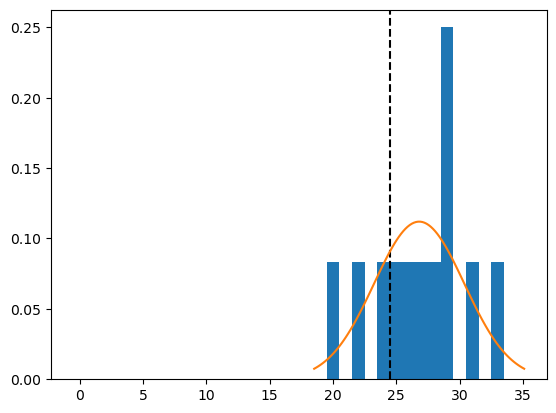

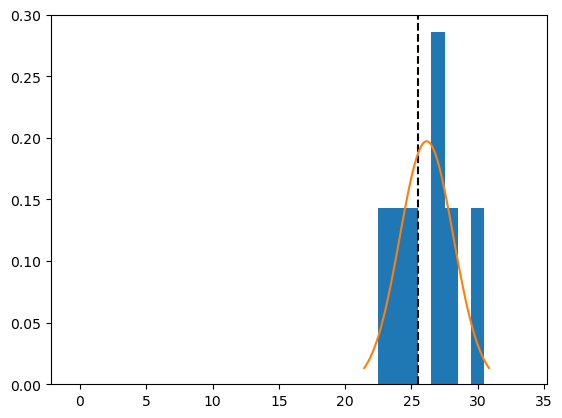

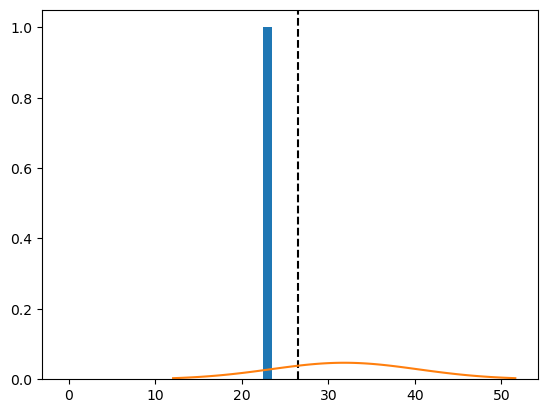

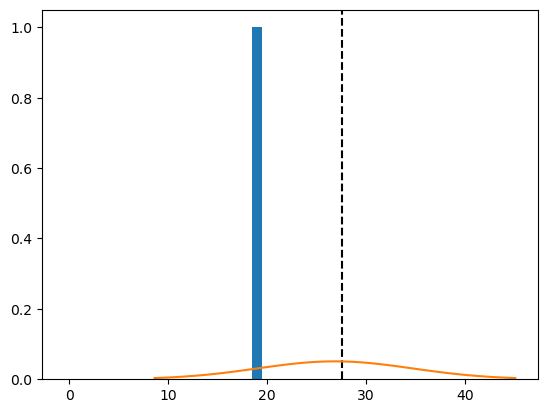

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


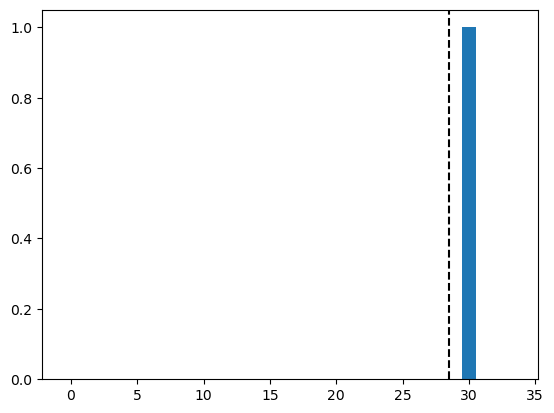

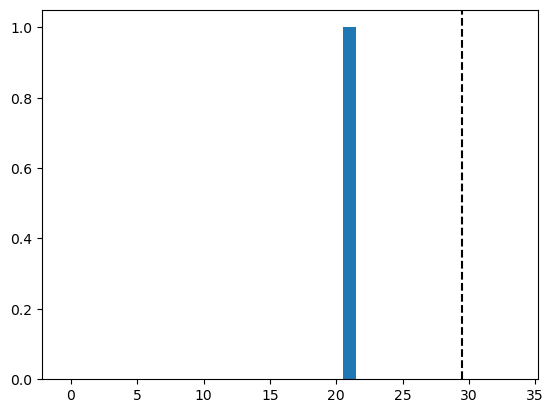

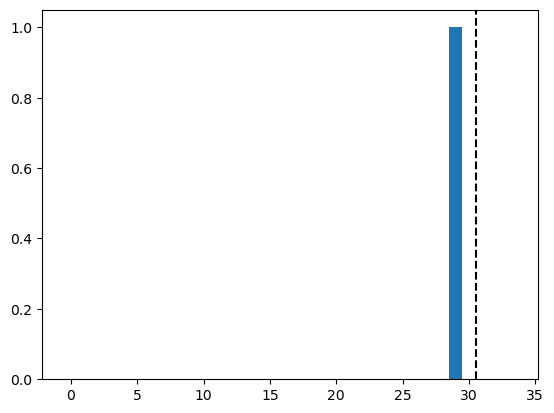

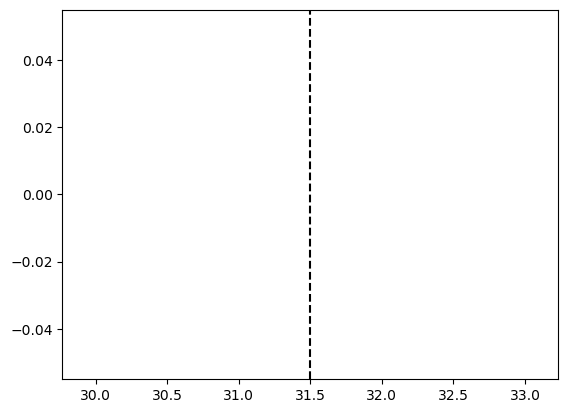

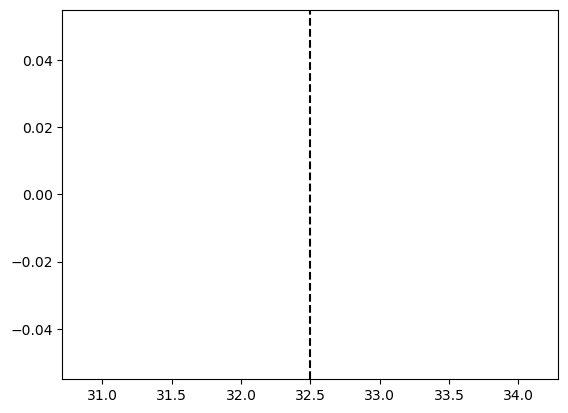

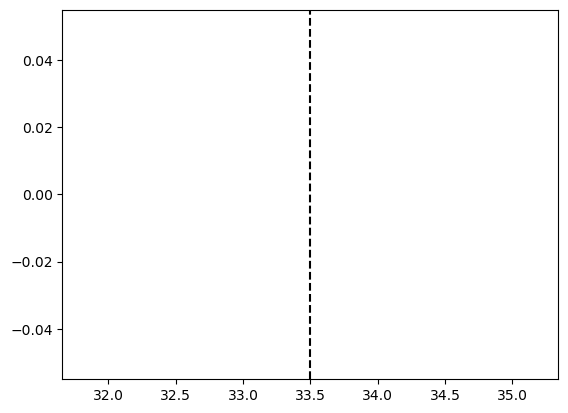

In [20]:
# lb, ub = norm.support()

for i, b in enumerate(binned_admissions):  # binned_predictions):
    loc = np.mean(b)
    scale = np.std(b)
    
    x = np.linspace(norm.ppf(0.01, loc=loc, scale=scale), norm.ppf(0.99, loc=loc, scale=scale), 100)

    fig, ax = plt.subplots()
    
    plt.hist(b, bins=bins, density=True)
    plt.axvline(bins[i], color='k', linestyle='--')
    ax.plot(x, norm.pdf(x, loc=loc, scale=scale))
    plt.show()

### Mean-std fit

Link means and stds using Ordinary Least Squares fit:

In [21]:
w = np.where(np.array(binned_lengths) >= 200)

In [22]:
Y = np.array(binned_stds)[w]
X = np.array(binned_means)[w]
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.params

array([1.29641264, 0.13206646])

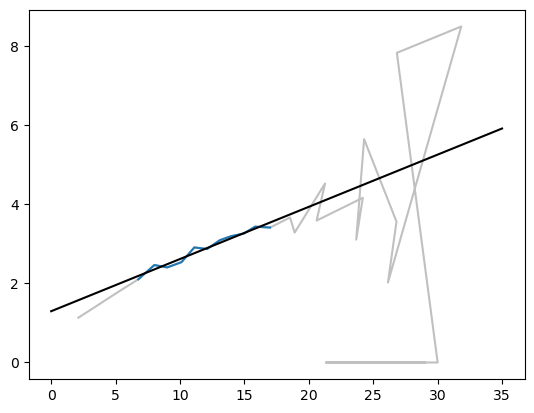

In [23]:


plt.plot(binned_means, binned_stds, color='silver')
plt.plot(np.array(binned_means)[w], np.array(binned_stds)[w])

x = np.linspace(0, np.nanmax(binned_means)+1, 100)
y = 1.29641264 + 0.13206646*x
plt.plot(x, y, color='k')

plt.show()

### Confidence interval test

This isn't useful - delete

In [24]:
def calculate_ci(vals, s=1.96):
    r = np.std(vals) / np.sqrt(len(vals))
    
    ci_top = np.mean(vals) + s * r
    ci_low = np.mean(vals) - s * r
    return ci_top, ci_low

In [25]:
binned_ci = []

for i, a in enumerate(binned_admissions):  # binned_predictions):
    ci_top, ci_low = calculate_ci(a)
    binned_ci.append([ci_low, ci_top])

In [26]:
for i, a in enumerate(binned_admissions):  # binned_predictions):
    print(f'{i:2.0f} {binned_ci[i][0]:5.2f} {np.mean(a):5.2f} {binned_ci[i][1]:5.2f} {len(a):3.0f}')

 0   nan   nan   nan   0
 1   nan   nan   nan   0
 2   nan   nan   nan   0
 3  0.83  2.11  3.39   3
 4  2.58  3.58  4.58   8
 5  3.75  4.29  4.84  33
 6  5.28  5.62  5.97 113
 7  6.51  6.76  7.02 254
 8  7.79  8.01  8.23 493
 9  8.84  9.01  9.18 754
10  9.95 10.11 10.27 933
11 10.92 11.11 11.31 869
12 11.91 12.10 12.30 816
13 12.86 13.09 13.32 700
14 13.71 13.98 14.25 540
15 14.64 14.95 15.26 422
16 15.41 15.84 16.27 246
17 16.52 16.99 17.47 200
18 17.93 18.54 19.15 139
19 18.14 18.90 19.66  72
20 20.12 21.26 22.41  60
21 19.53 20.60 21.68  43
22 22.81 24.19 25.57  35
23 22.38 23.68 24.98  22
24 20.38 24.29 28.21   8
25 24.79 26.81 28.82  12
26 24.64 26.14 27.64   7
27 20.05 31.83 43.61   2
28 15.98 26.83 37.69   2
29 30.00 30.00 30.00   1
30 21.33 21.33 21.33   1
31 29.00 29.00 29.00   1
32   nan   nan   nan   0
33   nan   nan   nan   0
34 34.00 34.00 34.00   1


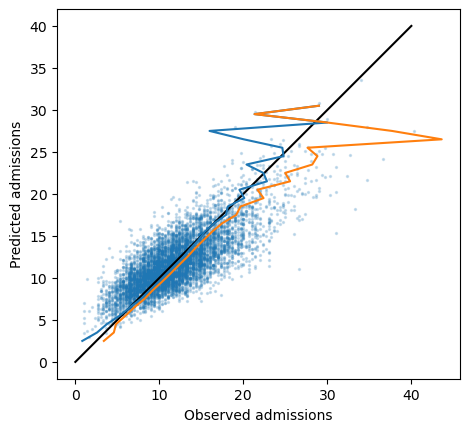

In [27]:
fig, ax = plt.subplots()

ax.scatter(observed_all, predicted_all, s=2, alpha=0.2)
ax.plot([0, 40], [0, 40], color='k')

# CI:
ax.plot([binned_ci[i][0] for i in range(len(binned_ci))], bins)
ax.plot([binned_ci[i][1] for i in range(len(binned_ci))], bins)
 
ax.set_aspect('equal')
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Predicted admissions')

plt.show()

### Test - consistency of multiple smaller groups of mSOA

In [28]:
def many_sum_sqres(individual, x_lists, admissions_lists):
    # Predictions for each MSOA:
    predictions_lists = []
    sum_sqres_by_depriv = []
    for i in range(5):
        coeffs = individual[(i*5):(i*5)+5]  # coeffs for this depriv.
        yhat = predict_admissions(x_lists[i], coeffs)
        sum_sqres = find_square_residuals(yhat, admissions_lists[i])
        predictions_lists.append(yhat)
        sum_sqres_by_depriv.append(sum_sqres)


    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate sum of square residuals across all MSOA:
    sum_sqres = find_square_residuals(predicted_all, observed_all)

    return sum_sqres, sum_sqres_by_depriv

In [29]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

In [30]:
len(df_stats)

6790

In [31]:
inds_available = np.arange(len(df_stats))
n_splits = 10
# n_inds = int(len(df_stats) / n_splits)

inds_splits = []
for i in range(n_splits):
    size = int(len(inds_available) / (n_splits - i))
    inds = np.random.choice(inds_available, size=size, replace=False)
    inds_splits.append(inds)
    inds_available = list(set(inds_available) - set(inds))

In [32]:
dict_splits = {}

for i, inds in enumerate(inds_splits):
    df_stats_ind = df_stats[inds]
    
    admissions_lists_ind = []
    x_lists_ind = []
    for qmin in qmin_list:
        df_stats_here = df_stats_ind.filter(df_stats_ind['depriv_quantile_min'] == qmin)
        # MSOA data in the same order as those coefficients:
        x_lists_here = [df_stats_here[a] for a in age_numbers]
        admissions_here = df_stats_here['admissions'].to_numpy().tolist()
        # Store:
        admissions_lists_ind.append(admissions_here)
        x_lists_ind.append(x_lists_here)

    dict_splits[i] = {
        'size': len(inds),
        'inds': inds,
        'admissions_lists': admissions_lists_ind,
        'admissions_total': sum(sum(admissions_lists_ind, [])),
        'x_lists': x_lists_ind,
    }

In [33]:
for i, d in dict_splits.items():
    sum_sqres, sum_sqres_by_depriv = many_sum_sqres(best_coeffs, d['x_lists'], d['admissions_lists'])
    d['sum_sqres'] = sum_sqres
    for s, sum_sqres_q in enumerate(sum_sqres_by_depriv):
        label = f'sum_sqres_{quantile_str_list[s]}'
        d[label] = sum_sqres_q

In [34]:
for k, d in dict_splits.items():
    print(d['sum_sqres'], d['admissions_total'], d['sum_sqres']/d['admissions_total'])

78.92050527792543 8168.666666683004 0.00966136929051264
74.43445182187763 8109.3333333030005 0.00917886203002582
71.23953405240498 8025.999999989994 0.008876094449600523
75.49193559069802 8012.0000000130085 0.009422358411205124
75.30182125035418 7914.666666686992 0.009514212590569508
74.603074039855 8191.999999968003 0.009106820561541308
78.60225599934071 8240.333333342007 0.009538722867107882
78.69168556412599 8086.99999999201 0.009730639985681184
71.82319601262459 8150.333333329993 0.008812301666106175
75.59075127161812 8057.666666683006 0.009381220941314463


What's the mean sum sq res? Say one msoa has admissions pm this.

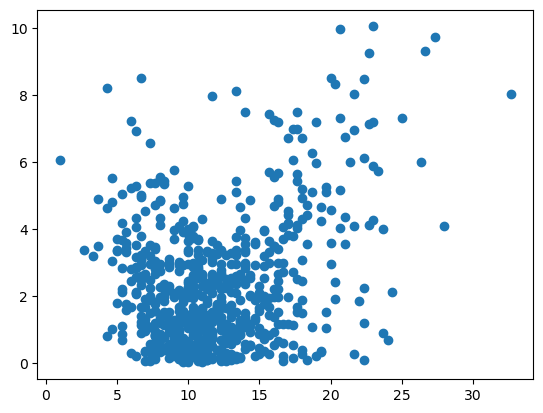

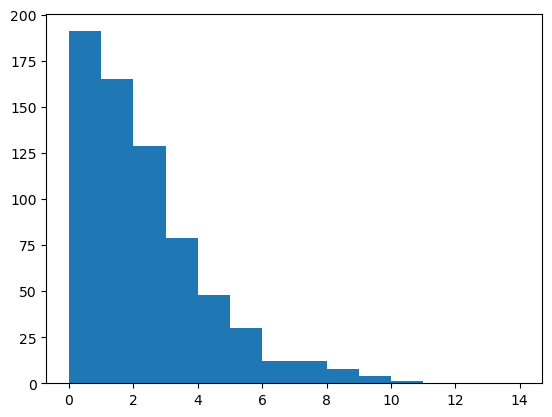

2.3428495630117823 10.038043298999998 0.008667219999999531


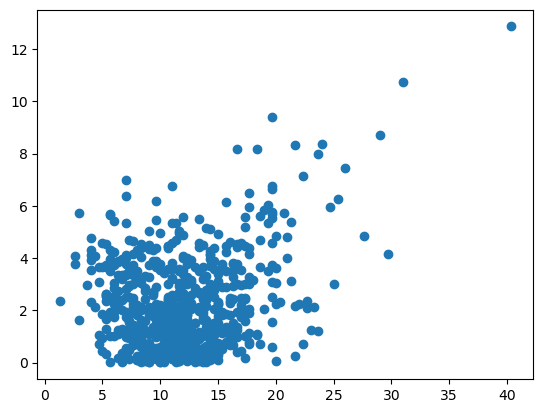

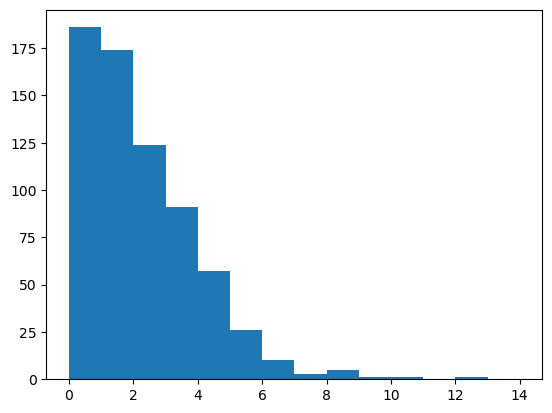

2.2396899755066273 12.868585192000001 0.0011346709999990878


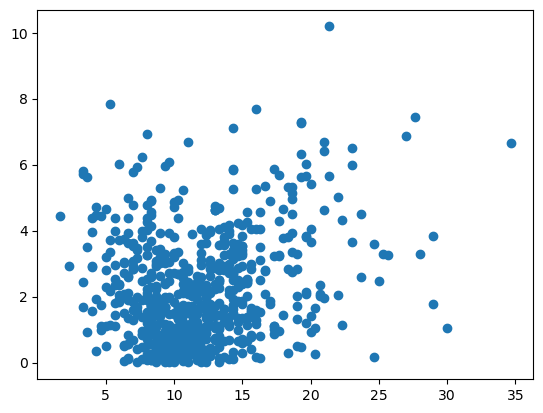

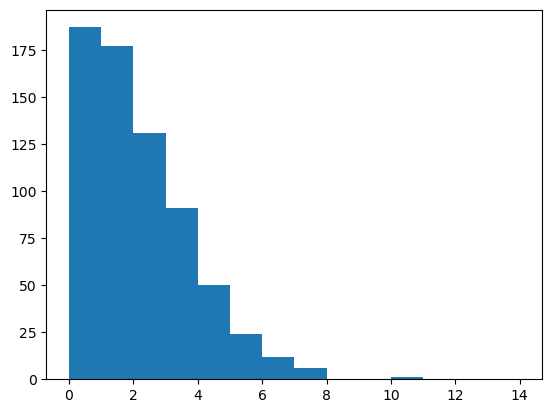

2.190679642232695 10.188339574 0.0031816069999983654


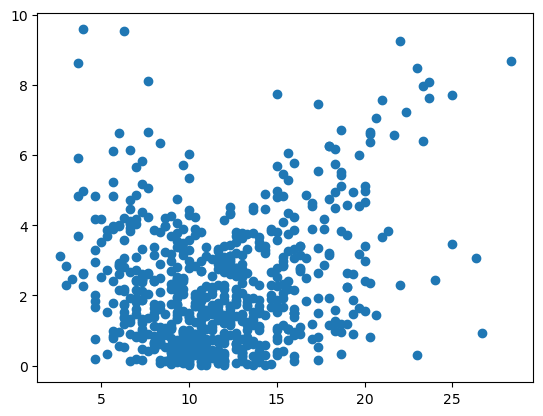

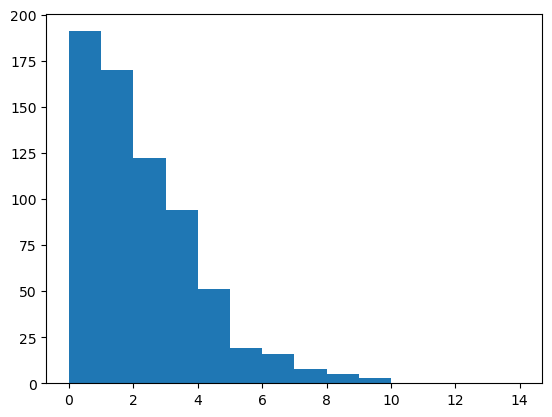

2.274476983736377 9.57332332 0.0013939189999980783


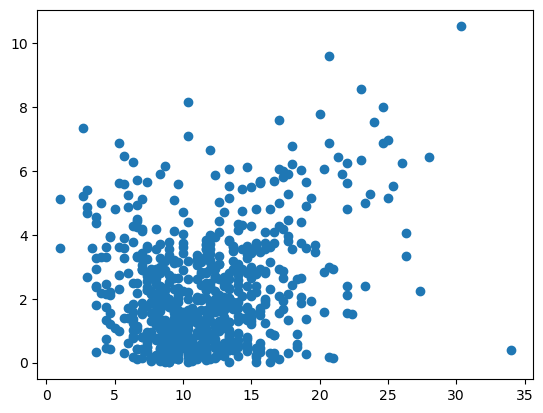

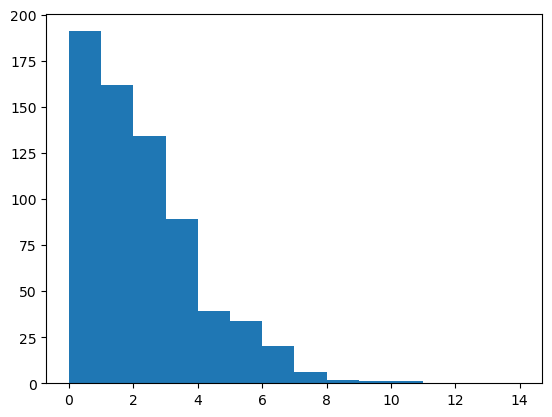

2.284592587533137 10.509407234000001 0.005887400000000653


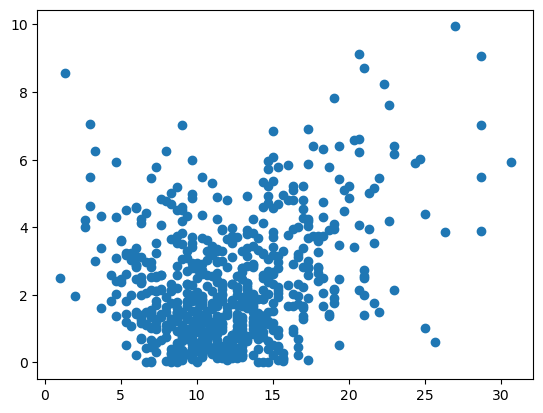

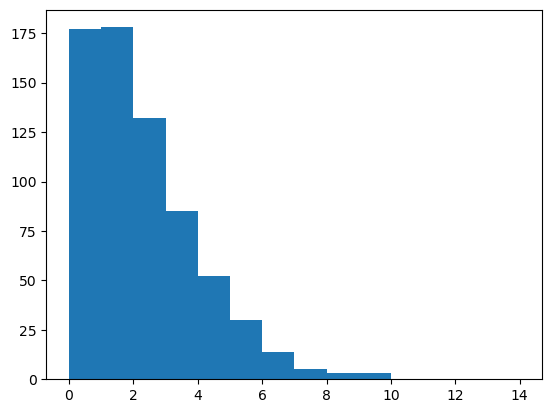

2.269457126435935 9.941105551000003 0.00025696899999871903


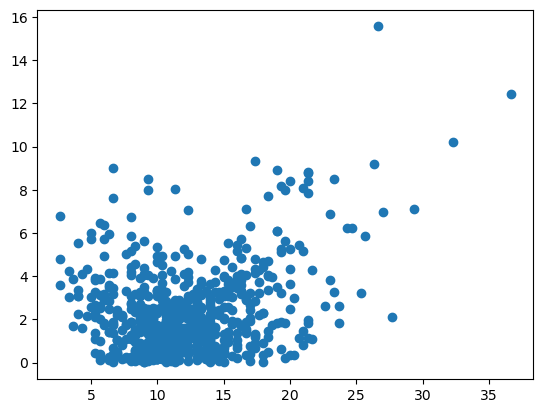

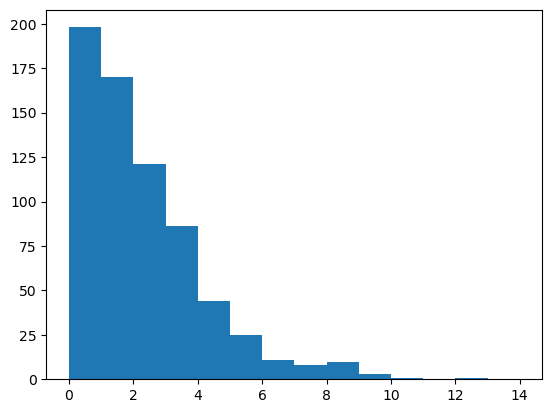

2.2804551433637705 15.568453423000001 0.0011129600000003848


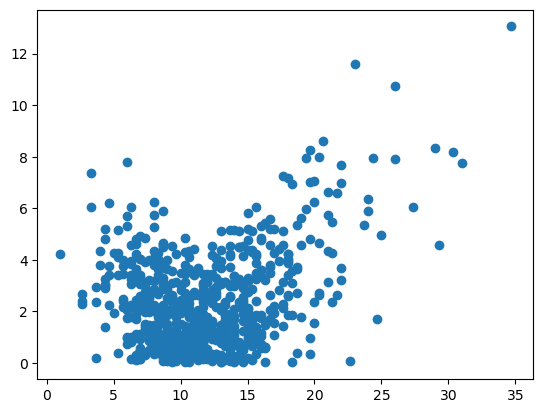

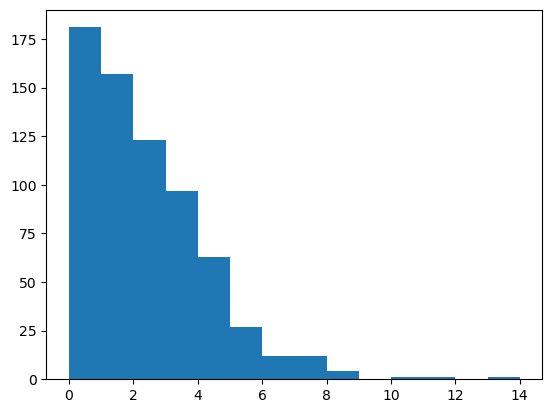

2.3689542604801175 13.052019066 0.016646001000001576


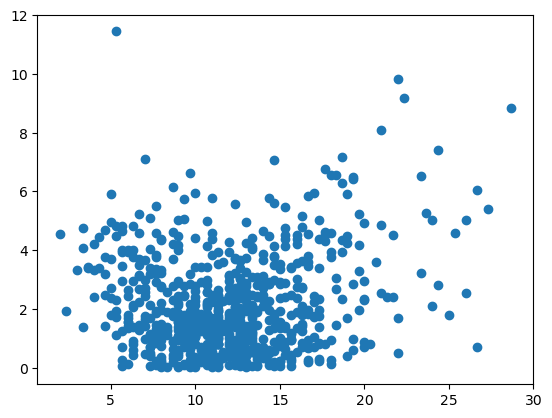

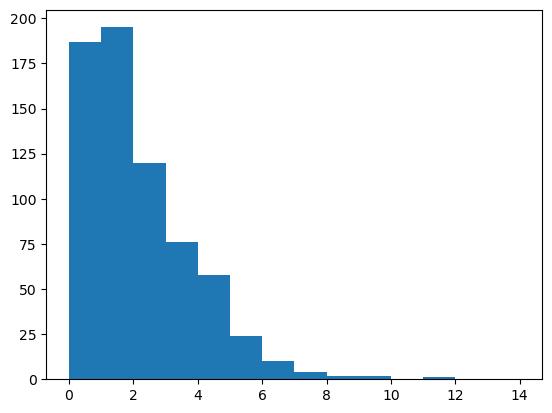

2.182493427189985 11.443921227 0.006422869000001441


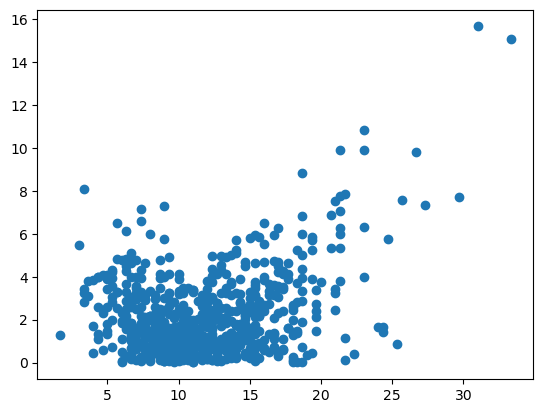

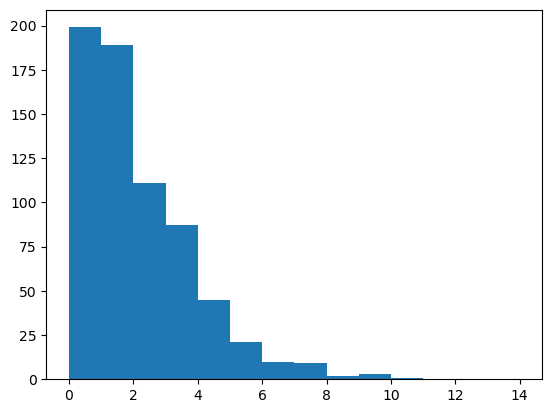

2.18489282389838 15.65728772 0.003746522999996671


In [35]:
for k, d in dict_splits.items():

    # Predictions for each MSOA:
    predictions_lists = []
    sqres_by_depriv = []
    for i in range(5):
        coeffs = best_coeffs[(i*5):(i*5)+5]  # coeffs for this depriv.
        yhat = predict_admissions(d['x_lists'][i], coeffs)
        # sum_sqres = find_square_residuals(yhat, admissions_lists[i])
        # Difference from actual:
        sqres_each = np.sqrt((np.array(yhat) - np.array(d['admissions_lists'][i]))**2.0)  # note sqrt
        predictions_lists.append(yhat)
        sqres_by_depriv.append(list(sqres_each))
        
    # Combine lists:
    observed_all = sum(d['admissions_lists'], [])
    predicted_all = sum(predictions_lists, [])
    sqres_all = sum(sqres_by_depriv, [])

    plt.scatter(observed_all, sqres_all)
    plt.show()

    plt.hist(sqres_all, bins=np.arange(0, 15, 1))
    plt.show()
    # 
    print(np.mean(sqres_all), np.max(sqres_all), np.min(sqres_all))